# Trip cost prediction

This notebook checks whether linear regression and tariff-specific models are suitable for predicting `total_amount` using the cleaned dataset `my_clean_3_with_weather.parquet`.

Important: we do not use direct components of `total_amount` as features: `fare_amount`, `tip_amount`, `tolls_amount`, `extra`, `mta_tax`, `airport_fee`, `congestion_surcharge`, `improvement_surcharge`, `calculated_amount`. Otherwise the model would leak the answer.

In [42]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("my_clean_3_with_weather.parquet")
TARGET = "total_amount"
RANDOM_STATE = 42

# Use samples so plots and model training run faster.
PLOT_SAMPLE_SIZE = 100_000
MODEL_SAMPLE_SIZE = 400_000

pd.set_option("display.max_columns", 100)

## 1. Загружаем очищенные данные

In [43]:
schema_cols = set(pq.read_schema(DATA_PATH).names)
duration_source_col = "duration_min" if "duration_min" in schema_cols else "trip_duration_min"

wanted_cols = [
    TARGET,
    "trip_distance",
    duration_source_col,
    "tpep_pickup_datetime",
    "pickup_hour",
    "distance_group",
    "passenger_count",
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type",
    "PULocationID",
    "DOLocationID",
    "PU_Borough",
    "DO_Borough",
    "PU_lon",
    "PU_lat",
    "DO_lon",
    "DO_lat",
    "temperature",
    "precipitation",
    "snowfall",
    "weather_code",
]
raw_cols = list(dict.fromkeys([col for col in wanted_cols if col in schema_cols]))

df = pd.read_parquet(DATA_PATH, columns=raw_cols)

if duration_source_col != "duration_min":
    df = df.rename(columns={duration_source_col: "duration_min"})

if "pickup_hour" not in df.columns:
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour.astype("int8")

if "distance_group" not in df.columns:
    df["distance_group"] = pd.cut(
        df["trip_distance"],
        bins=[-0.01, 1, 3, 7, 15, np.inf],
        labels=["very_short", "short", "medium", "long", "very_long"]
    ).astype("string")

# Airport trip feature is based on location IDs, not airport_fee,
# because airport_fee is a direct component of total_amount.
airport_location_ids = [1, 132, 138]  # Newark, JFK, LaGuardia
df["is_airport_trip"] = (
    df["PULocationID"].isin(airport_location_ids) |
    df["DOLocationID"].isin(airport_location_ids)
).astype("int8")

df["airport_pickup"] = df["PULocationID"].isin(airport_location_ids).astype("int8")
df["airport_dropoff"] = df["DOLocationID"].isin(airport_location_ids).astype("int8")
df["same_zone_trip"] = (df["PULocationID"] == df["DOLocationID"]).astype("int8")

# Time features. Cyclic encoding keeps 23:00 and 00:00 close to each other.
if "tpep_pickup_datetime" in df.columns:
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek.astype("int8")
    df["pickup_month"] = df["tpep_pickup_datetime"].dt.month.astype("int8")
else:
    df["pickup_day_of_week"] = 0
    df["pickup_month"] = 1

df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6]).astype("int8")
df["is_rush_hour"] = (
    df["pickup_hour"].between(7, 10) |
    df["pickup_hour"].between(17, 20)
).astype("int8")
df["is_night"] = ((df["pickup_hour"] >= 23) | (df["pickup_hour"] <= 6)).astype("int8")
df["is_weekend_night"] = (df["is_weekend"].eq(1) & df["is_night"].eq(1)).astype("int8")

df["sin_hour"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)
df["sin_day_of_week"] = np.sin(2 * np.pi * df["pickup_day_of_week"] / 7)
df["cos_day_of_week"] = np.cos(2 * np.pi * df["pickup_day_of_week"] / 7)

# Nonlinear helpers for a still-linear model.
df["log_trip_distance"] = np.log1p(df["trip_distance"].clip(lower=0))
df["log_duration_min"] = np.log1p(df["duration_min"].clip(lower=0))
df["avg_speed_mph"] = df["trip_distance"] / (df["duration_min"] / 60)
df["avg_speed_mph"] = df["avg_speed_mph"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Weather features. These are known at pickup time and do not leak fare components.
weather_numeric_cols = ["temperature", "precipitation", "snowfall"]
for col in weather_numeric_cols:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

if "weather_code" not in df.columns:
    df["weather_code"] = 0
df["weather_code"] = df["weather_code"].astype("string").fillna("Unknown")

df["has_precipitation"] = (df["precipitation"] > 0).astype("int8")
df["has_snow"] = (df["snowfall"] > 0).astype("int8")
df["bad_weather"] = ((df["precipitation"] > 0) | (df["snowfall"] > 0)).astype("int8")
df["freezing_weather"] = (df["temperature"] <= 0).astype("int8")
df["temperature_x_precipitation"] = df["temperature"] * df["precipitation"]

print("File:", DATA_PATH)
print("Table shape:", df.shape)
print("Duration column used:", duration_source_col)
print("Total missing values:", int(df.isna().sum().sum()))
display(df.head())

File: my_clean_3_with_weather.parquet
Table shape: (7655312, 45)
Duration column used: duration_min
Total missing values: 0


,total_amount,trip_distance,duration_min,tpep_pickup_datetime,distance_group,passenger_count,VendorID,RatecodeID,store_and_fwd_flag,payment_type,PULocationID,DOLocationID,PU_Borough,DO_Borough,PU_lon,PU_lat,DO_lon,DO_lat,temperature,precipitation,snowfall,weather_code,pickup_hour,is_airport_trip,airport_pickup,airport_dropoff,same_zone_trip,pickup_day_of_week,pickup_month,is_weekend,is_rush_hour,is_night,is_weekend_night,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,log_trip_distance,log_duration_min,avg_speed_mph,has_precipitation,has_snow,bad_weather,freezing_weather,temperature_x_precipitation
0,11.20,1.17,4.683333,2023-01-29 17:52:02,short,1,2,1.0,N,2,262,74,Manhattan,Manhattan,-73.946510,40.775932,-73.937346,40.801169,9.6,0.0,0.0,3,17,0,0,0,0,6,1,1,1,0,0,-0.965926,-0.258819,-0.781831,0.623490,0.774727,1.737538,14.989324,0,0,0,0,0.00
1,10.50,0.90,5.383333,2023-01-08 15:57:24,very_short,1,1,1.0,N,2,229,237,Manhattan,Manhattan,-73.965146,40.756729,-73.965635,40.768615,4.2,0.0,0.0,3,15,0,0,0,0,6,1,1,0,0,0,-0.707107,-0.707107,-0.781831,0.623490,0.641854,1.853690,10.030960,0,0,0,0,0.00
2,14.28,0.95,7.016667,2023-01-21 19:38:01,very_short,1,2,1.0,N,1,45,261,Manhattan,Manhattan,-73.998151,40.712459,-74.013023,40.709139,3.1,0.0,0.0,3,19,0,0,0,0,5,1,1,1,0,0,-0.965926,0.258819,-0.974928,-0.222521,0.667829,2.081523,8.123515,0,0,0,0,0.00
3,24.30,0.88,19.250000,2023-01-23 16:07:31,very_short,5,2,1.0,N,1,237,141,Manhattan,Manhattan,-73.965635,40.768615,-73.959635,40.766948,2.9,0.6,0.0,53,16,0,0,0,0,0,1,0,0,0,0,-0.866025,-0.500000,0.000000,1.000000,0.631272,3.008155,2.742857,1,0,1,0,1.74
4,13.80,1.03,3.666667,2023-01-26 21:21:08,short,2,2,1.0,N,1,229,140,Manhattan,Manhattan,-73.965146,40.756729,-73.954739,40.765484,5.0,0.0,0.0,1,21,0,0,0,0,3,1,0,0,0,0,-0.707107,0.707107,0.433884,-0.900969,0.708036,1.540445,16.854545,0,0,0,0,0.00


In [44]:
display(df[[TARGET, "trip_distance", "duration_min"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

print("Минимальная стоимость:", df[TARGET].min())
print("Максимальная стоимость:", df[TARGET].max())

,count,mean,std,min,50%,90%,95%,99%,max
total_amount,7655312.0,28.304813,21.021156,0.0,21.0,56.950000,81.240000,102.440000,500.00
trip_distance,7655312.0,3.412691,4.315600,0.0,1.8,8.920000,14.530000,19.810000,94.99
duration_min,7655312.0,16.635923,13.421685,1.0,12.9,32.566667,43.133333,67.733333,298.65


Минимальная стоимость: 0.0
Максимальная стоимость: 500.0


## 2. Графики для проверки линейной связи

Линейная регрессия ожидает, что целевая переменная примерно линейно связана с признаками. Поэтому сначала смотрим `trip_distance -> total_amount` и `duration_min -> total_amount`.

In [45]:
plot_sample = df.sample(
    n=min(PLOT_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE
).copy()

print("Размер сэмпла для графиков:", plot_sample.shape)

Размер сэмпла для графиков: (100000, 45)


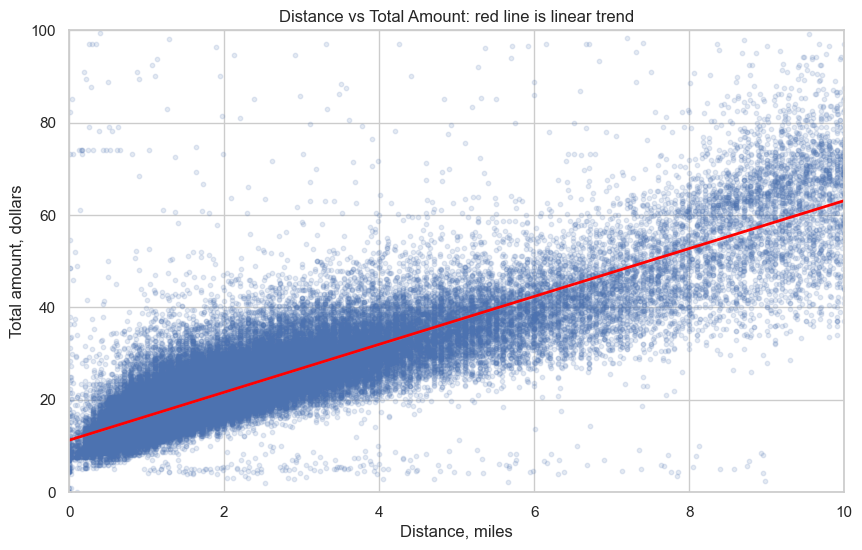

In [46]:
# Увеличенный график: основная масса городских поездок.
zoom_distance = plot_sample[
    plot_sample["trip_distance"].between(0, 10) &
    plot_sample[TARGET].between(0, 100)
].copy()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=zoom_distance,
    x="trip_distance",
    y=TARGET,
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Distance vs Total Amount: red line is linear trend")
plt.xlabel("Distance, miles")
plt.ylabel("Total amount, dollars")
plt.xlim(0, 10)
plt.ylim(0, 100)
plt.show()

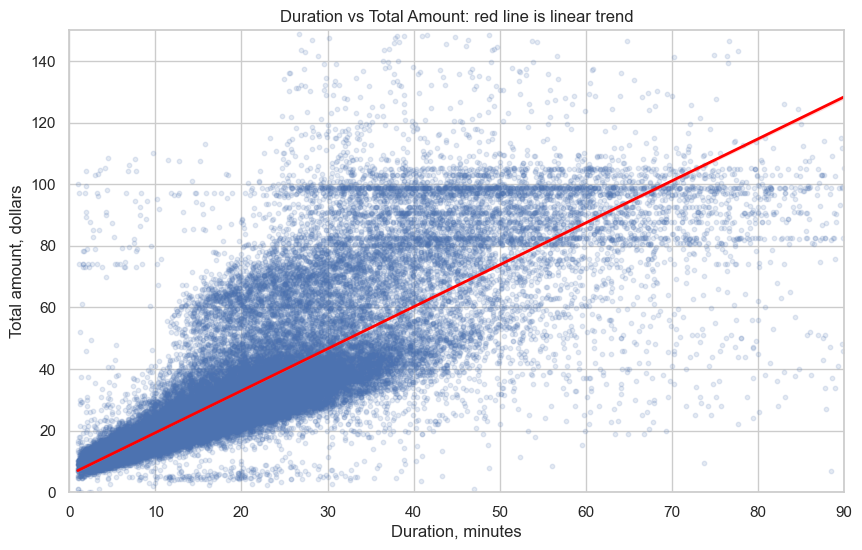

In [47]:
zoom_duration = plot_sample[
    plot_sample["duration_min"].between(0, 90) &
    plot_sample[TARGET].between(0, 150)
].copy()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=zoom_duration,
    x="duration_min",
    y=TARGET,
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Duration vs Total Amount: red line is linear trend")
plt.xlabel("Duration, minutes")
plt.ylabel("Total amount, dollars")
plt.xlim(0, 90)
plt.ylim(0, 150)
plt.show()

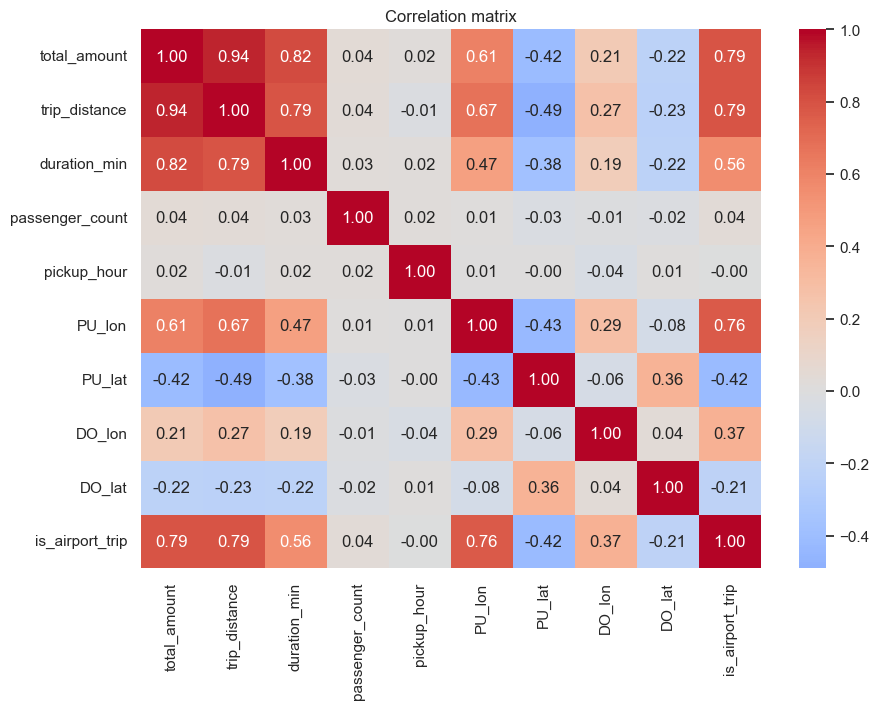

In [48]:
corr_cols = [
    TARGET,
    "trip_distance",
    "duration_min",
    "passenger_count",
    "pickup_hour",
    "PU_lon",
    "PU_lat",
    "DO_lon",
    "DO_lat",
    "is_airport_trip",
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    plot_sample[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation matrix")
plt.show()

## 3. Train Linear Regression

This block trains ordinary least squares linear regression.

The tariff-aware variant adds interaction features for `RatecodeID`: distance, duration, log-distance, log-duration, rush hour, and night flags are allowed to have different slopes for each tariff.

In [49]:
def regression_metrics(y_true, y_pred):
    """Calculate core regression metrics."""
    y_true = np.asarray(y_true, dtype="float64")
    y_pred = np.asarray(y_pred, dtype="float64")
    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    within_5 = np.mean(np.abs(error) <= 5)
    within_10 = np.mean(np.abs(error) <= 10)
    return {
        "MAE_$": mae,
        "RMSE_$": rmse,
        "R2": r2,
        "within_$5": within_5,
        "within_$10": within_10,
    }


def make_design_matrix(train_df, valid_df, numeric_features, categorical_features, interaction_features=None):
    """Prepare X: numeric + one-hot categorical + optional interaction features."""
    interaction_features = interaction_features or []
    all_df = pd.concat([train_df, valid_df], axis=0, ignore_index=True)

    X_parts = []

    if numeric_features:
        X_num = all_df[numeric_features].astype("float32")
        X_parts.append(X_num)

    if categorical_features:
        X_cat_source = all_df[categorical_features].copy()
        for col in categorical_features:
            X_cat_source[col] = X_cat_source[col].astype("string").fillna("Unknown")

        X_cat = pd.get_dummies(
            X_cat_source,
            columns=categorical_features,
            drop_first=True,
            dtype="float32"
        )
        X_parts.append(X_cat)

    for base_col, group_col in interaction_features:
        if base_col not in all_df.columns or group_col not in all_df.columns:
            continue

        group_values = all_df[group_col].astype("string").fillna("Unknown")
        group_dummies = pd.get_dummies(group_values, prefix=group_col, dtype="float32")
        interaction_part = group_dummies.mul(all_df[base_col].astype("float32"), axis=0)
        interaction_part = interaction_part.add_prefix(f"{base_col}_x_")
        X_parts.append(interaction_part)

    if not X_parts:
        raise ValueError("At least one feature is required")

    X = pd.concat(X_parts, axis=1)
    feature_names = X.columns.to_list()

    X_train = X.iloc[:len(train_df)].to_numpy(dtype="float64")
    X_valid = X.iloc[len(train_df):].to_numpy(dtype="float64")

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1

    X_train_scaled = (X_train - mean) / std
    X_valid_scaled = (X_valid - mean) / std

    X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
    X_valid_design = np.column_stack([np.ones(len(X_valid_scaled)), X_valid_scaled])

    return X_train_design, X_valid_design, feature_names


def fit_ols(train_df, valid_df, numeric_features, categorical_features, target, interaction_features=None):
    X_train, X_valid, feature_names = make_design_matrix(
        train_df,
        valid_df,
        numeric_features,
        categorical_features,
        interaction_features=interaction_features
    )
    y_train = train_df[target].to_numpy(dtype="float64")
    y_valid = valid_df[target].to_numpy(dtype="float64")

    coefficients, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    train_pred = X_train @ coefficients
    valid_pred = X_valid @ coefficients

    return {
        "coefficients": coefficients,
        "feature_names": feature_names,
        "y_train": y_train,
        "y_valid": y_valid,
        "train_pred": train_pred,
        "valid_pred": valid_pred,
        "train_metrics": regression_metrics(y_train, train_pred),
        "valid_metrics": regression_metrics(y_valid, valid_pred),
    }

In [50]:
model_df = df.sample(
    n=min(MODEL_SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

rng = np.random.default_rng(RANDOM_STATE)
permutation = rng.permutation(len(model_df))
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[permutation[:split_idx]].reset_index(drop=True)
valid_df = model_df.iloc[permutation[split_idx:]].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)

Train: (320000, 45)
Validation: (80000, 45)


In [ ]:
business_numeric_features = [
    "trip_distance",
    "duration_min",
    "log_trip_distance",
    "log_duration_min",
    "avg_speed_mph",
    "passenger_count",
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "is_weekend_night",
    "sin_hour",
    "cos_hour",
    "sin_day_of_week",
    "cos_day_of_week",
    "PU_lon",
    "PU_lat",
    "DO_lon",
    "DO_lat",
    "is_airport_trip",
    "airport_pickup",
    "airport_dropoff",
    "same_zone_trip",
    "temperature",
    "precipitation",
    "snowfall",
    "has_precipitation",
    "has_snow",
    "bad_weather",
    "freezing_weather",
    "temperature_x_precipitation",
]

business_categorical_features = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag",
    "distance_group",
    "PU_Borough",
    "DO_Borough",
    "weather_code",
]

business_numeric_features = [col for col in business_numeric_features if col in train_df.columns]
business_categorical_features = [col for col in business_categorical_features if col in train_df.columns]

ratecode_interactions = [
    ("trip_distance", "RatecodeID"),
    ("duration_min", "RatecodeID"),
    ("log_trip_distance", "RatecodeID"),
    ("log_duration_min", "RatecodeID"),
    ("is_rush_hour", "RatecodeID"),
    ("is_night", "RatecodeID"),
    ("bad_weather", "RatecodeID"),
    ("precipitation", "RatecodeID"),
    ("snowfall", "RatecodeID"),
]

model_specs = [
    {
        "name": "1_distance_only",
        "numeric": ["trip_distance"],
        "categorical": [],
        "interactions": [],
    },
    {
        "name": "2_distance_duration",
        "numeric": ["trip_distance", "duration_min"],
        "categorical": [],
        "interactions": [],
    },
    {
        "name": "3_business_features",
        "numeric": business_numeric_features,
        "categorical": business_categorical_features,
        "interactions": [],
    },
    {
        "name": "4_ratecode_specific_slopes",
        "numeric": business_numeric_features,
        "categorical": business_categorical_features,
        "interactions": ratecode_interactions,
    },
]

fitted_models = {}
rows = []

for spec in model_specs:
    fitted = fit_ols(
        train_df=train_df,
        valid_df=valid_df,
        numeric_features=spec["numeric"],
        categorical_features=spec["categorical"],
        interaction_features=spec.get("interactions", []),
        target=TARGET,
    )
    fitted_models[spec["name"]] = fitted

    row = {"model": spec["name"]}
    row.update({f"train_{k}": v for k, v in fitted["train_metrics"].items()})
    row.update({f"valid_{k}": v for k, v in fitted["valid_metrics"].items()})
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values("valid_MAE_$").reset_index(drop=True)
display(metrics_df.round(4))

best_model_name = metrics_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
print("Best model by validation MAE:", best_model_name)
print("Business numeric features:", business_numeric_features)
print("Business categorical features:", business_categorical_features)
print("Ratecode interactions:", ratecode_interactions)

,model,train_MAE_$,train_RMSE_$,train_R2,train_within_$5,train_within_$10,valid_MAE_$,valid_RMSE_$,valid_R2,valid_within_$5,valid_within_$10
0,4_ratecode_specific_slopes,2.2562,4.0205,0.9634,0.9007,0.9733,2.2523,4.0825,0.9626,0.9021,0.9738
1,3_business_features,2.6009,4.8622,0.9464,0.8813,0.9595,2.6074,4.9577,0.9449,0.8814,0.9602
2,2_distance_duration,3.5604,6.7434,0.8969,0.8283,0.9283,3.5977,6.8688,0.8942,0.8265,0.9275
3,1_distance_only,4.5024,7.3651,0.8771,0.7318,0.9062,4.5574,7.5184,0.8733,0.7297,0.9038


Best model by validation MAE: 4_ratecode_specific_slopes
Business numeric features: ['trip_distance', 'duration_min', 'log_trip_distance', 'log_duration_min', 'avg_speed_mph', 'passenger_count', 'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_weekend_night', 'sin_hour', 'cos_hour', 'sin_day_of_week', 'cos_day_of_week', 'PU_lon', 'PU_lat', 'DO_lon', 'DO_lat', 'is_airport_trip', 'airport_pickup', 'airport_dropoff', 'same_zone_trip', 'temperature', 'precipitation', 'snowfall', 'has_precipitation', 'has_snow', 'bad_weather', 'freezing_weather', 'temperature_x_precipitation']
Business categorical features: ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'distance_group', 'PU_Borough', 'DO_Borough', 'weather_code']
Ratecode interactions: [('trip_distance', 'RatecodeID'), ('duration_min', 'RatecodeID'), ('log_trip_distance', 'RatecodeID'), ('log_duration_min', 'RatecodeID'), ('is_rush_hour', 'RatecodeID'), ('is_night', 'Ratec

In [ ]:
per_ratecode_models = {}
per_ratecode_rows = []
per_ratecode_predictions = []

per_ratecode_numeric_features = [
    col for col in business_numeric_features
    if col in train_df.columns
]
per_ratecode_categorical_features = [
    col for col in business_categorical_features
    if col in train_df.columns and col != "RatecodeID"
]

min_train_rows_per_ratecode = 50

for ratecode in sorted(valid_df["RatecodeID"].dropna().unique()):
    rate_train = train_df[train_df["RatecodeID"] == ratecode].copy()
    rate_valid = valid_df[valid_df["RatecodeID"] == ratecode].copy()

    if len(rate_valid) == 0:
        continue

    if len(rate_train) < min_train_rows_per_ratecode:
        per_ratecode_rows.append({
            "RatecodeID": ratecode,
            "train_rows": len(rate_train),
            "valid_rows": len(rate_valid),
            "status": "skipped_not_enough_train_rows",
            "MAE_$": np.nan,
            "RMSE_$": np.nan,
            "R2": np.nan,
            "within_$5": np.nan,
            "within_$10": np.nan,
        })
        continue

    fitted = fit_ols(
        train_df=rate_train,
        valid_df=rate_valid,
        numeric_features=per_ratecode_numeric_features,
        categorical_features=per_ratecode_categorical_features,
        target=TARGET,
        interaction_features=[],
    )

    per_ratecode_models[ratecode] = fitted

    rate_result = pd.DataFrame({
        "RatecodeID": ratecode,
        "actual": fitted["y_valid"],
        "predicted": fitted["valid_pred"],
    })
    rate_result["error"] = rate_result["actual"] - rate_result["predicted"]
    rate_result["abs_error"] = rate_result["error"].abs()
    per_ratecode_predictions.append(rate_result)

    row = {
        "RatecodeID": ratecode,
        "train_rows": len(rate_train),
        "valid_rows": len(rate_valid),
        "status": "trained",
    }
    row.update(fitted["valid_metrics"])
    per_ratecode_rows.append(row)

per_ratecode_metrics = pd.DataFrame(per_ratecode_rows).sort_values("RatecodeID").reset_index(drop=True)

if per_ratecode_predictions:
    per_ratecode_result = pd.concat(per_ratecode_predictions, ignore_index=True)
    per_ratecode_result["abs_error"] = per_ratecode_result["error"].abs()
    per_ratecode_overall_metrics = pd.Series({
        "model": "5_separate_model_per_ratecode",
        "validation_rows": len(per_ratecode_result),
        "MAE_$": per_ratecode_result["abs_error"].mean(),
        "RMSE_$": np.sqrt(np.mean(per_ratecode_result["error"] ** 2)),
        "mean_error_$": per_ratecode_result["error"].mean(),
        "median_abs_error_$": per_ratecode_result["abs_error"].median(),
        "p90_abs_error_$": per_ratecode_result["abs_error"].quantile(0.90),
        "p95_abs_error_$": per_ratecode_result["abs_error"].quantile(0.95),
        "share_error_within_$5": (per_ratecode_result["abs_error"] <= 5).mean(),
        "share_error_within_$10": (per_ratecode_result["abs_error"] <= 10).mean(),
    })
else:
    per_ratecode_result = pd.DataFrame()
    per_ratecode_overall_metrics = pd.Series(dtype="float64")

display(per_ratecode_metrics.round(4))
display(per_ratecode_overall_metrics.to_frame("value"))

,RatecodeID,train_rows,valid_rows,status,MAE_$,RMSE_$,R2,within_$5,within_$10
0,1.0,285000,71185,trained,1.7828,2.9633,0.9659,0.9423,0.9885
1,2.0,11573,2963,trained,4.9887,7.1403,0.4350,0.6186,0.8927
2,3.0,963,244,trained,8.8707,12.1002,0.8705,0.4057,0.6721
3,4.0,85,22,trained,37.7992,70.2625,-0.2776,0.1364,0.3182
4,5.0,614,163,trained,18.5326,26.6509,0.5215,0.1840,0.4049
5,99.0,21765,5423,trained,4.4181,6.9154,0.7073,0.7297,0.9085


,value
model,5_separate_model_per_ratecode
validation_rows,80000
MAE_$,2.145825
RMSE_$,4.024297
mean_error_$,-0.00026
median_abs_error_$,1.303654
p90_abs_error_$,4.633396
p95_abs_error_$,6.795715
share_error_within_$5,0.912512
share_error_within_$10,0.97715


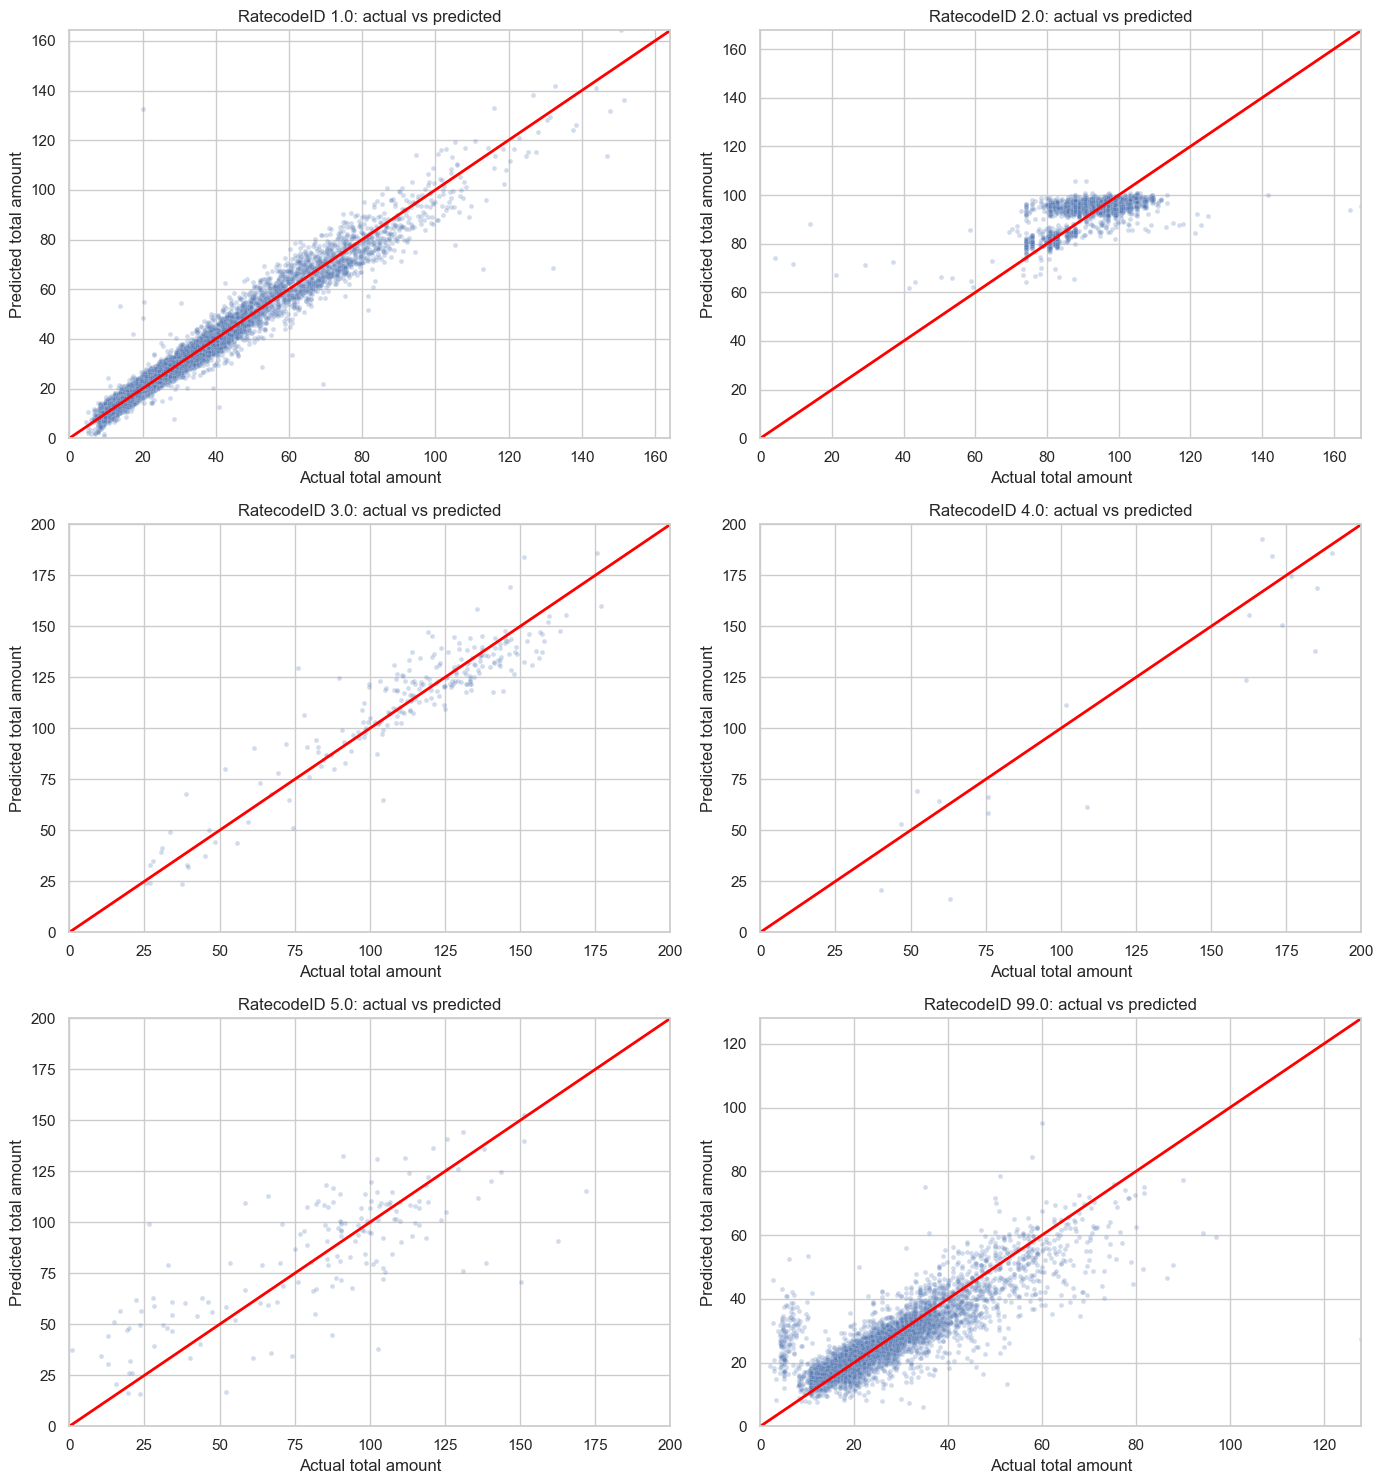

In [ ]:
if per_ratecode_result.empty:
    print("No per-ratecode predictions to plot.")
else:
    ratecodes = sorted(per_ratecode_result["RatecodeID"].unique())
    ncols = 2
    nrows = int(np.ceil(len(ratecodes) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7 * ncols, 5 * nrows))
    axes = np.asarray(axes).reshape(-1)

    for ax, ratecode in zip(axes, ratecodes):
        plot_data = per_ratecode_result[per_ratecode_result["RatecodeID"] == ratecode]
        plot_data = plot_data.sample(n=min(20_000, len(plot_data)), random_state=RANDOM_STATE)

        sns.scatterplot(
            data=plot_data,
            x="actual",
            y="predicted",
            alpha=0.25,
            s=12,
            ax=ax
        )

        max_value = max(plot_data["actual"].max(), plot_data["predicted"].max())
        limit = min(200, max_value)
        ax.plot([0, limit], [0, limit], color="red", linewidth=2)
        ax.set_xlim(0, limit)
        ax.set_ylim(0, limit)
        ax.set_title(f"RatecodeID {ratecode}: actual vs predicted")
        ax.set_xlabel("Actual total amount")
        ax.set_ylabel("Predicted total amount")

    for ax in axes[len(ratecodes):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

## 4. Проверяем качество и валидность прогноза

Смотрим не только метрики, но и графики ошибок. Хороший знак: точки `actual vs predicted` лежат близко к красной диагонали, а остатки на графике `residuals` не образуют явную дугу или веер.

In [54]:
valid_result = pd.DataFrame({
    "actual": best_model["y_valid"],
    "predicted": best_model["valid_pred"],
    "RatecodeID": valid_df["RatecodeID"].to_numpy(),
})
valid_result["error"] = valid_result["actual"] - valid_result["predicted"]
valid_result["abs_error"] = valid_result["error"].abs()

quality_summary = pd.Series({
    "validation_rows": len(valid_result),
    "MAE_$": valid_result["abs_error"].mean(),
    "RMSE_$": np.sqrt(np.mean(valid_result["error"] ** 2)),
    "R2": best_model["valid_metrics"]["R2"],
    "predicted_below_0_count": int((valid_result["predicted"] < 0).sum()),
    "predicted_below_0_share": (valid_result["predicted"] < 0).mean(),
    "share_error_within_$5": (valid_result["abs_error"] <= 5).mean(),
    "share_error_within_$10": (valid_result["abs_error"] <= 10).mean(),
})

display(quality_summary)

validation_rows            80000.000000
MAE_$                          2.252345
RMSE_$                         4.082468
R2                             0.962635
predicted_below_0_count        4.000000
predicted_below_0_share        0.000050
share_error_within_$5          0.902088
share_error_within_$10         0.973838
dtype: float64

In [55]:
error_summary = pd.Series({
    "model": best_model_name,
    "MAE_$": valid_result["abs_error"].mean(),
    "RMSE_$": np.sqrt(np.mean(valid_result["error"] ** 2)),
    "mean_error_$": valid_result["error"].mean(),
    "median_abs_error_$": valid_result["abs_error"].median(),
    "p90_abs_error_$": valid_result["abs_error"].quantile(0.90),
    "p95_abs_error_$": valid_result["abs_error"].quantile(0.95),
    "share_error_within_$5": (valid_result["abs_error"] <= 5).mean(),
    "share_error_within_$10": (valid_result["abs_error"] <= 10).mean(),
    "predicted_below_0_count": int((valid_result["predicted"] < 0).sum()),
})

display(error_summary)

print(f"Average model error: {error_summary['MAE_$']:.2f} $")
print(f"Median absolute error: {error_summary['median_abs_error_$']:.2f} $")
print(f"95% of trips have error below {error_summary['p95_abs_error_$']:.2f} $")

model                      4_ratecode_specific_slopes
MAE_$                                        2.252345
RMSE_$                                       4.082468
mean_error_$                                -0.003617
median_abs_error_$                           1.363091
p90_abs_error_$                              4.933646
p95_abs_error_$                              7.322004
share_error_within_$5                        0.902088
share_error_within_$10                       0.973838
predicted_below_0_count                             4
dtype: object

Average model error: 2.25 $
Median absolute error: 1.36 $
95% of trips have error below 7.32 $


In [56]:
ratecode_rows = []
for ratecode, group in valid_result.groupby("RatecodeID"):
    ratecode_rows.append({
        "RatecodeID": ratecode,
        "rows": len(group),
        "MAE_$": group["abs_error"].mean(),
        "RMSE_$": np.sqrt(np.mean(group["error"] ** 2)),
        "median_abs_error_$": group["abs_error"].median(),
        "p90_abs_error_$": group["abs_error"].quantile(0.90),
        "p95_abs_error_$": group["abs_error"].quantile(0.95),
        "share_error_within_$5": (group["abs_error"] <= 5).mean(),
        "share_error_within_$10": (group["abs_error"] <= 10).mean(),
    })

ratecode_quality = pd.DataFrame(ratecode_rows).sort_values("MAE_$")
display(ratecode_quality.round(4))

,RatecodeID,rows,MAE_$,RMSE_$,median_abs_error_$,p90_abs_error_$,p95_abs_error_$,share_error_within_$5,share_error_within_$10
0,1.0,71185,1.8207,2.9897,1.2369,3.8426,5.4122,0.9405,0.9883
5,99.0,5423,4.6740,7.2026,3.1076,10.2095,16.0875,0.7039,0.8969
1,2.0,2963,6.4071,8.4805,5.5963,11.7196,14.0236,0.4360,0.8394
2,3.0,244,10.2494,13.7159,8.2119,19.7793,25.6016,0.3238,0.5697
3,4.0,22,18.3203,23.0718,15.1316,33.2427,41.3363,0.0909,0.3636
4,5.0,163,20.5237,29.8247,14.4053,43.5650,56.3079,0.1656,0.3497


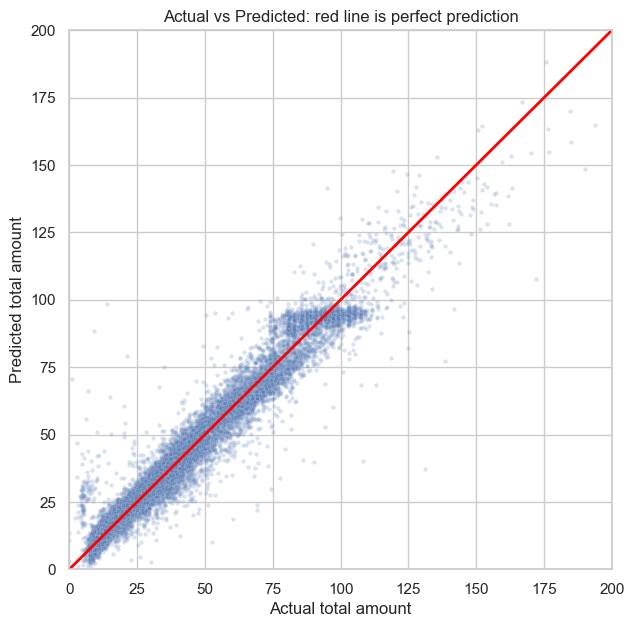

In [57]:
plot_pred = valid_result.sample(
    n=min(50_000, len(valid_result)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=plot_pred,
    x="actual",
    y="predicted",
    alpha=0.2,
    s=10
)

max_value = max(plot_pred["actual"].max(), plot_pred["predicted"].max())
plt.plot([0, max_value], [0, max_value], color="red", linewidth=2)
plt.title("Actual vs Predicted: red line is perfect prediction")
plt.xlabel("Actual total amount")
plt.ylabel("Predicted total amount")
plt.xlim(0, min(200, max_value))
plt.ylim(0, min(200, max_value))
plt.show()

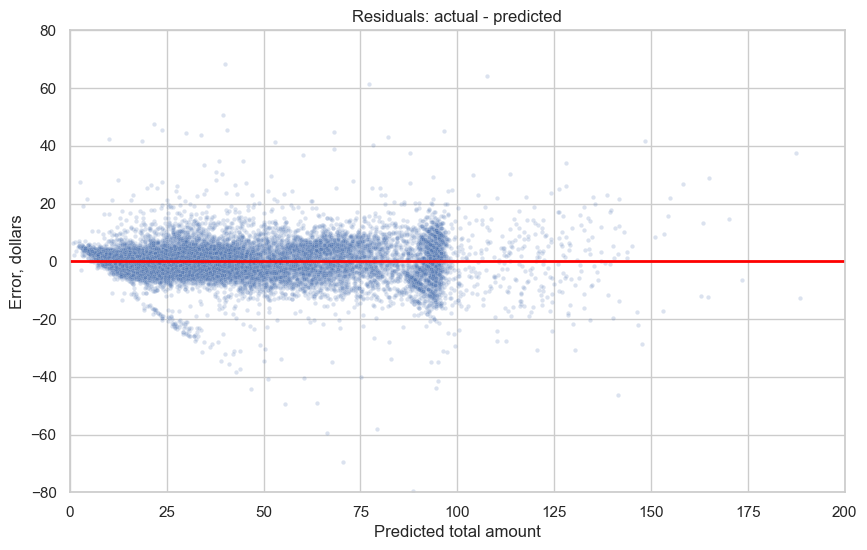

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_pred,
    x="predicted",
    y="error",
    alpha=0.2,
    s=10
)
plt.axhline(0, color="red", linewidth=2)
plt.title("Residuals: actual - predicted")
plt.xlabel("Predicted total amount")
plt.ylabel("Error, dollars")
plt.xlim(0, 200)
plt.ylim(-80, 80)
plt.show()

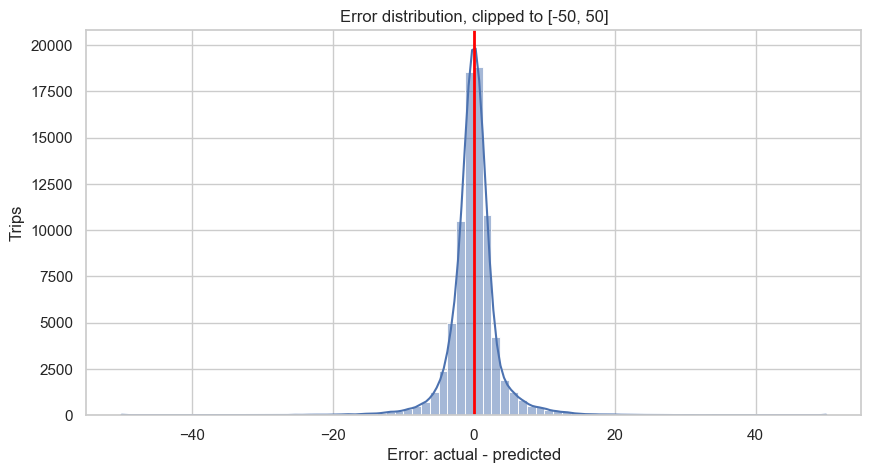

In [59]:
plt.figure(figsize=(10, 5))
sns.histplot(
    valid_result["error"].clip(-50, 50),
    bins=80,
    kde=True
)
plt.axvline(0, color="red", linewidth=2)
plt.title("Error distribution, clipped to [-50, 50]")
plt.xlabel("Error: actual - predicted")
plt.ylabel("Trips")
plt.show()

## 5. Смотрим важные коэффициенты

Коэффициенты ниже показаны после стандартизации признаков. Поэтому их удобно сравнивать между собой: чем дальше коэффициент от нуля, тем сильнее вклад признака в линейную модель.

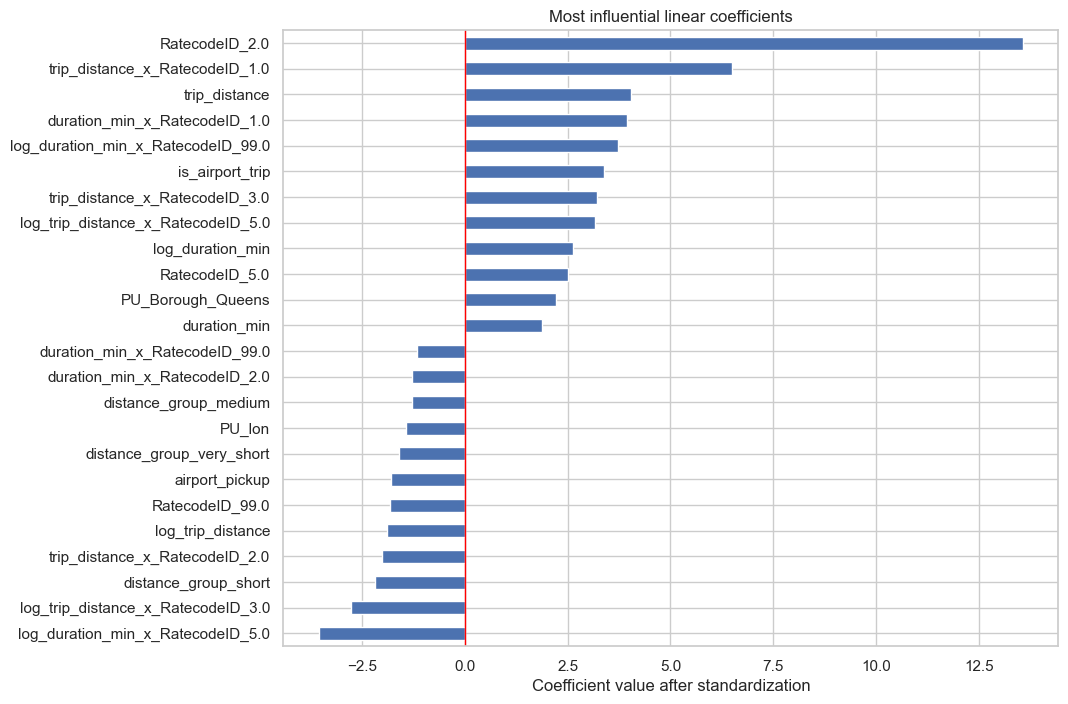

In [60]:
coef_series = pd.Series(
    best_model["coefficients"][1:],
    index=best_model["feature_names"]
)

top_coef = pd.concat([
    coef_series.sort_values().head(12),
    coef_series.sort_values().tail(12)
])

plt.figure(figsize=(10, 8))
top_coef.sort_values().plot(kind="barh")
plt.axvline(0, color="red", linewidth=1)
plt.title("Most influential linear coefficients")
plt.xlabel("Coefficient value after standardization")
plt.show()